# Unsupervised Learning: Trade & Ahead

## Problem Statement

### Context

The stock market has consistently proven to be a good place to invest in and save for the future. There are a lot of compelling reasons to invest in stocks. It can help in fighting inflation, create wealth, and also provides some tax benefits. Good steady returns on investments over a long period of time can also grow a lot more than seems possible. Also, thanks to the power of compound interest, the earlier one starts investing, the larger the corpus one can have for retirement. Overall, investing in stocks can help meet life's financial aspirations.

It is important to maintain a diversified portfolio when investing in stocks in order to maximise earnings under any market condition. Having a diversified portfolio tends to yield higher returns and face lower risk by tempering potential losses when the market is down. It is often easy to get lost in a sea of financial metrics to analyze while determining the worth of a stock, and doing the same for a multitude of stocks to identify the right picks for an individual can be a tedious task. By doing a cluster analysis, one can identify stocks that exhibit similar characteristics and ones which exhibit minimum correlation. This will help investors better analyze stocks across different market segments and help protect against risks that could make the portfolio vulnerable to losses.


### Objective

Trade&Ahead is a financial consultancy firm who provide their customers with personalized investment strategies. They have hired you as a Data Scientist and provided you with data comprising stock price and some financial indicators for a few companies listed under the New York Stock Exchange. They have assigned you the tasks of analyzing the data, grouping the stocks based on the attributes provided, and sharing insights about the characteristics of each group.

### Data Dictionary

- Ticker Symbol: An abbreviation used to uniquely identify publicly traded shares of a particular stock on a particular stock market
- Company: Name of the company
- GICS Sector: The specific economic sector assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- GICS Sub Industry: The specific sub-industry group assigned to a company by the Global Industry Classification Standard (GICS) that best defines its business operations
- Current Price: Current stock price in dollars
- Price Change: Percentage change in the stock price in 13 weeks
- Volatility: Standard deviation of the stock price over the past 13 weeks
- ROE: A measure of financial performance calculated by dividing net income by shareholders' equity (shareholders' equity is equal to a company's assets minus its debt)
- Cash Ratio: The ratio of a  company's total reserves of cash and cash equivalents to its total current liabilities
- Net Cash Flow: The difference between a company's cash inflows and outflows (in dollars)
- Net Income: Revenues minus expenses, interest, and taxes (in dollars)
- Earnings Per Share: Company's net profit divided by the number of common shares it has outstanding (in dollars)
- Estimated Shares Outstanding: Company's stock currently held by all its shareholders
- P/E Ratio: Ratio of the company's current stock price to the earnings per share
- P/B Ratio: Ratio of the company's stock price per share by its book value per share (book value of a company is the net difference between that company's total assets and total liabilities)

## Importing necessary libraries and data

In [58]:
# Installing the libraries with the specified version.
# uncomment and run the following line if Google Colab is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.3 yellowbrick==1.5 -q --user

In [59]:
# Installing the libraries with the specified version.
# uncomment and run the following lines if Jupyter Notebook is being used
# !pip install scikit-learn==1.2.2 seaborn==0.13.1 matplotlib==3.7.1 numpy==1.25.2 pandas==1.5.2 yellowbrick==1.5 -q --user
# !pip install --upgrade -q jinja2

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [60]:
#start with the basics for data manipulation and visualization
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# to scale the data using z-score
from sklearn.preprocessing import StandardScaler

# to compute distances
from scipy.spatial.distance import cdist, pdist

# to perform k-means clustering and compute silhouette scores
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# hierarchical clustering, compute cophenetic correlation, and dendrograms
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage, cophenet

# visualize the elbow curve and silhouette scores
from yellowbrick.cluster import KElbowVisualizer, SilhouetteVisualizer

# suppress warnings
import warnings
warnings.filterwarnings('ignore')

In [61]:
# mount my drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [62]:
# read the dataset
data=pd.read_csv('/content/drive/My Drive/UTAustinDataScience/datafiles/stock_data.csv')

In [119]:
# convert ipnb to HTML file
%cd /content/drive/MyDrive/Colab\ Notebooks


!jupyter nbconvert USL_Project_LearnerNotebook_FullCode.ipynb --to html

/content/drive/MyDrive/Colab Notebooks
[NbConvertApp] Converting notebook USL_Project_LearnerNotebook_FullCode.ipynb to html
[NbConvertApp] Writing 2223304 bytes to USL_Project_LearnerNotebook_FullCode.html


## Data Overview

- Observations
- Sanity checks

In [64]:
data.head().sort_values(by='Current Price', ascending=False)

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
243,PCLN,Priceline.com Inc,Consumer Discretionary,Internet & Direct Marketing Retail,1274.949951,3.190527,1.268340,29,184,-1671386000,2551360000,50.09,5.093552e+07,25.453183,-1.052429
26,AMZN,Amazon.com Inc,Consumer Discretionary,Internet & Direct Marketing Retail,675.890015,32.268105,1.460386,4,58,1333000000,596000000,1.28,4.656250e+08,528.039074,3.904430
171,ISRG,Intuitive Surgical Inc.,Health Care,Health Care Equipment,546.159973,18.733013,1.126009,14,317,114300000,588800000,15.87,3.710145e+07,34.414617,42.607500
264,REGN,Regeneron,Health Care,Biotechnology,542.869995,16.995320,1.802345,17,129,160383000,636056000,6.17,1.030885e+08,87.985412,20.409000
70,CMG,Chipotle Mexican Grill,Consumer Discretionary,Restaurants,479.850006,-33.131268,2.474002,22,237,-171460000,475602000,15.30,3.108510e+07,31.362745,17.201329
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33,ARNC,Arconic Inc,Industrials,Aerospace & Defense,7.398807,1.647784,2.592065,3,37,42000000,-322000000,-0.31,1.038710e+09,18.687607,2.639814
284,SWN,Southwestern Energy,Energy,Oil & Gas Exploration & Production,7.110000,-44.798137,4.580042,200,2,-38000000,-4556000000,-6.07,4.021417e+08,93.089287,1.273530
127,FCX,Freeport-McMoran Cp & Gld,Materials,Copper,6.770000,-31.685167,3.796410,155,5,-240000000,-12156000000,-11.31,1.074801e+09,22.811951,2.935427
137,FTR,Frontier Communications,Telecommunications Services,Integrated Telecommunications Services,4.670000,-2.301255,2.026818,3,496,254000000,-196000000,-0.29,6.758621e+08,14.518987,10.497704


In [65]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 340 entries, 0 to 339
Data columns (total 15 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Ticker Symbol                 340 non-null    object 
 1   Security                      340 non-null    object 
 2   GICS Sector                   340 non-null    object 
 3   GICS Sub Industry             340 non-null    object 
 4   Current Price                 340 non-null    float64
 5   Price Change                  340 non-null    float64
 6   Volatility                    340 non-null    float64
 7   ROE                           340 non-null    int64  
 8   Cash Ratio                    340 non-null    int64  
 9   Net Cash Flow                 340 non-null    int64  
 10  Net Income                    340 non-null    int64  
 11  Earnings Per Share            340 non-null    float64
 12  Estimated Shares Outstanding  340 non-null    float64
 13  P/E R

#### Observation: There are 15 columns, 11 with numeric types and 4 that are objects.

In [66]:
data.shape

(340, 15)

#### Observation: There are 15 columns and 340 rows of data.

## Exploratory Data Analysis (EDA)

- EDA is an important part of any project involving data.
- It is important to investigate and understand the data better before building a model with it.
- A few questions have been mentioned below which will help you approach the analysis in the right manner and generate insights from the data.
- A thorough analysis of the data, in addition to the questions mentioned below, should be done.

In [67]:
#setting up histogram/boxplot function for univariate analysis
def histogram_boxplot(data, feature, figsize=(15, 10), kde=False, bins=None):
    """
    Boxplot and histogram combined


    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (15,10))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [68]:
# function to create labeled barplots


def labeled_barplot(df, feature, perc=False, n=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(df[feature])  # length of the column
    count = df[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 1, 5))
    else:
        plt.figure(figsize=(n + 1, 5))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=df,
        x=feature,
        order=df[feature].value_counts().index[:n].sort_values(),
    )

    for p in ax.patches:
        if perc == True:
            label = "{:.1f}%".format(
                100 * p.get_height() / total
            )  # percentage of each class of the category
        else:
            label = p.get_height()  # count of each level of the category

        x = p.get_x() + p.get_width() / 2  # width of the plot
        y = p.get_height()  # height of the plot

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="center",
            size=12,
            xytext=(0, 5),
            textcoords="offset points",
        )  # annotate the percentage

    plt.show()  # show the plot

**Questions**:

1. What does the distribution of stock prices look like?
2. The stocks of which economic sector have seen the maximum price increase on average?
3. How are the different variables correlated with each other?
4. Cash ratio provides a measure of a company's ability to cover its short-term obligations using only cash and cash equivalents. How does the average cash ratio vary across economic sectors?
5. P/E ratios can help determine the relative value of a company's shares as they signify the amount of money an investor is willing to invest in a single share of a company per dollar of its earnings. How does the P/E ratio vary, on average, across economic sectors?

## Distribution of Stock Prices

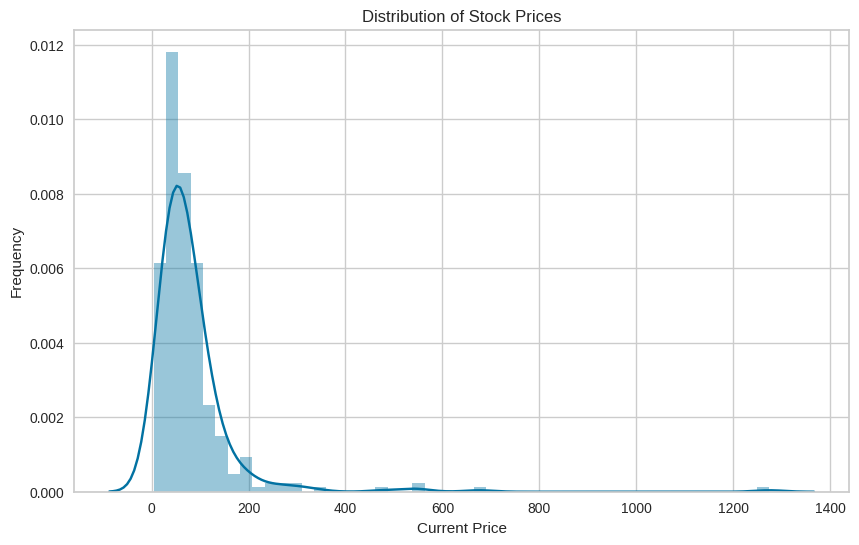

In [69]:
plt.figure(figsize=(10,6))
plt.title('Distribution of Stock Prices')
sns.distplot(data['Current Price'])
plt.xlabel('Current Price')
plt.ylabel('Frequency')
plt.show()

#### The distribution of stock prices has a normal bell shape, but is right-skewed. Some stocks are much more valuable than others.

## The stocks of which economic sector have seen the maximum price increase on average?

In [70]:
# Group the data by GICS Sector and calculate the average price change for each sector
sector_avg_price_change = data.groupby('GICS Sector')['Price Change'].mean().reset_index()

# Find the sector with the maximum average price increase
max_price_change_sector = sector_avg_price_change.loc[sector_avg_price_change['Price Change'].idxmax()]

# Sort the average price change in descending order for better understanding
sector_avg_price_change_sorted = sector_avg_price_change.sort_values(by='Price Change', ascending=False)

# Display the sorted table and the sector with the maximum price increase
print("Sector with maximum average price increase:\n", max_price_change_sector)

# Display the sorted table
print("\nAverage price change by sector:\n", sector_avg_price_change_sorted)


Sector with maximum average price increase:
 GICS Sector     Health Care
Price Change       9.585652
Name: 4, dtype: object

Average price change by sector:
                     GICS Sector  Price Change
4                   Health Care      9.585652
1              Consumer Staples      8.684750
6        Information Technology      7.217476
9   Telecommunications Services      6.956980
8                   Real Estate      6.205548
0        Consumer Discretionary      5.846093
7                     Materials      5.589738
3                    Financials      3.865406
5                   Industrials      2.833127
10                    Utilities      0.803657
2                        Energy    -10.228289


#### The Health Care sector has had the maximum price increase followed by Consumer Staples and Info Tech.

## How are the different variables correlated with each other?

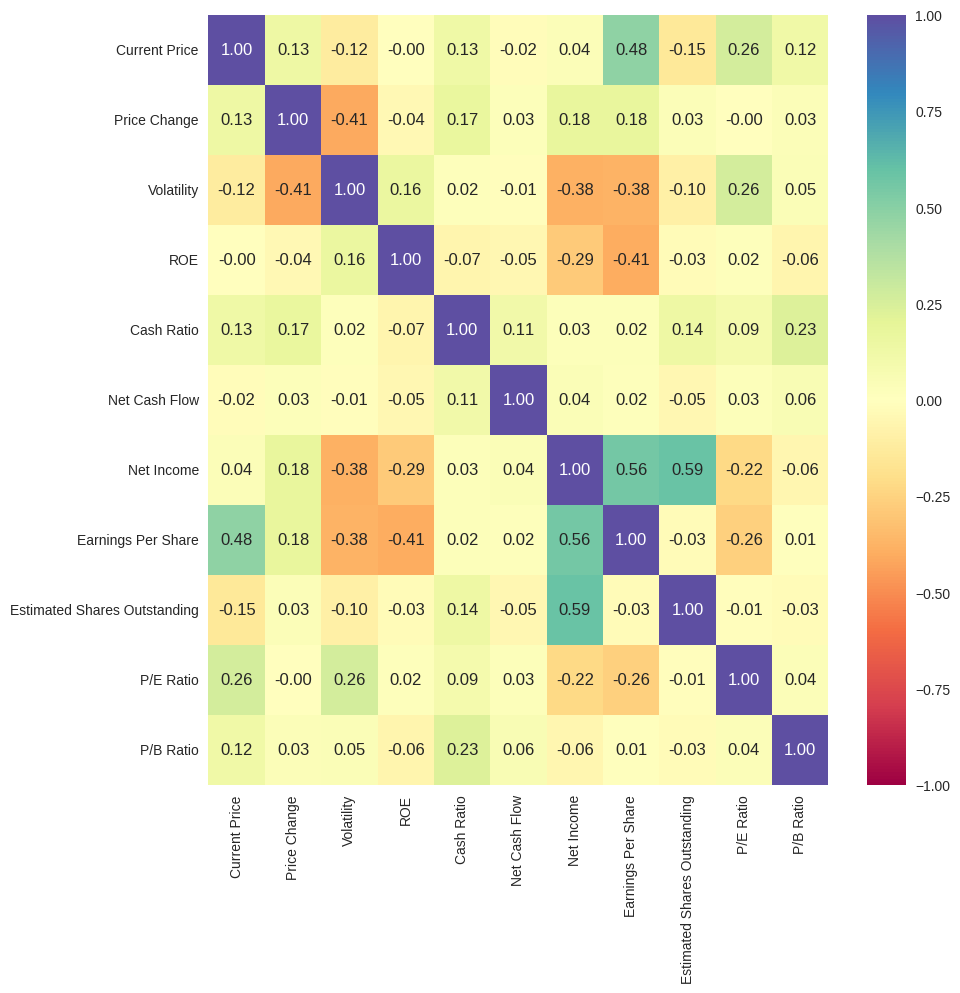

In [71]:
numeric_data = data.select_dtypes(include=['float64', 'int64'])
plt.figure(figsize=(10, 10))
sns.heatmap(numeric_data.corr(), annot=True, vmin=-1, vmax=1, fmt=".2f", cmap="Spectral")
plt.show()

#### Observation:

There are positive correlations between Net Income and Earnings Per Share and Estimated Shares Outstanding.

There are also postive correlations between:
P/E ratio and Volatility

Cash Ratio and P/B Ratio

There is a negative correlation between Price Change and Volatility.

## How does the average cash ratio vary across economic sectors?

In [72]:
data.groupby('GICS Sector')['Cash Ratio'].mean().sort_values(ascending=False)

,Cash Ratio
GICS Sector,
Information Technology,149.818182
Telecommunications Services,117.000000
Health Care,103.775000
Financials,98.591837
Consumer Staples,70.947368
Energy,51.133333
Real Estate,50.111111
Consumer Discretionary,49.575000
Materials,41.700000


#### Observation: Information Technology, Telecommunications and Healthcare have the highest cash ratio, in that order.

## How does the P/E ratio vary, on average, across economic sectors?

In [73]:
data.groupby('GICS Sector')['P/E Ratio'].mean().sort_values(ascending=False)

,P/E Ratio
GICS Sector,
Energy,72.897709
Information Technology,43.782546
Real Estate,43.065585
Health Care,41.135272
Consumer Discretionary,35.211613
Consumer Staples,25.521195
Materials,24.585352
Utilities,18.719412
Industrials,18.259380


#### Observation: Energy, Informaton Technology and Real Estate have the highest P/E ratios.

## Data Preprocessing

- Duplicate value check
- Missing value treatment
- Outlier check
- Feature engineering (if needed)
- Any other preprocessing steps (if needed)

In [74]:
data.duplicated().sum()

0

In [75]:
data.isna().sum()

,0
Ticker Symbol,0
Security,0
GICS Sector,0
GICS Sub Industry,0
Current Price,0
Price Change,0
Volatility,0
ROE,0
Cash Ratio,0
Net Cash Flow,0


In [76]:
data.isnull().sum()

,0
Ticker Symbol,0
Security,0
GICS Sector,0
GICS Sub Industry,0
Current Price,0
Price Change,0
Volatility,0
ROE,0
Cash Ratio,0
Net Cash Flow,0


#### Observation: No missing data treatment is needed.

In [77]:
data.describe()

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
count,340.000000,340.000000,340.000000,340.000000,340.000000,3.400000e+02,3.400000e+02,340.000000,3.400000e+02,340.000000,340.000000
mean,80.862345,4.078194,1.525976,39.597059,70.023529,5.553762e+07,1.494385e+09,2.776662,5.770283e+08,32.612563,-1.718249
std,98.055086,12.006338,0.591798,96.547538,90.421331,1.946365e+09,3.940150e+09,6.587779,8.458496e+08,44.348731,13.966912
min,4.500000,-47.129693,0.733163,1.000000,0.000000,-1.120800e+10,-2.352800e+10,-61.200000,2.767216e+07,2.935451,-76.119077
25%,38.555000,-0.939484,1.134878,9.750000,18.000000,-1.939065e+08,3.523012e+08,1.557500,1.588482e+08,15.044653,-4.352056
50%,59.705000,4.819505,1.385593,15.000000,47.000000,2.098000e+06,7.073360e+08,2.895000,3.096751e+08,20.819876,-1.067170
75%,92.880001,10.695493,1.695549,27.000000,99.000000,1.698108e+08,1.899000e+09,4.620000,5.731175e+08,31.764755,3.917066
max,1274.949951,55.051683,4.580042,917.000000,958.000000,2.076400e+10,2.444200e+10,50.090000,6.159292e+09,528.039074,129.064585


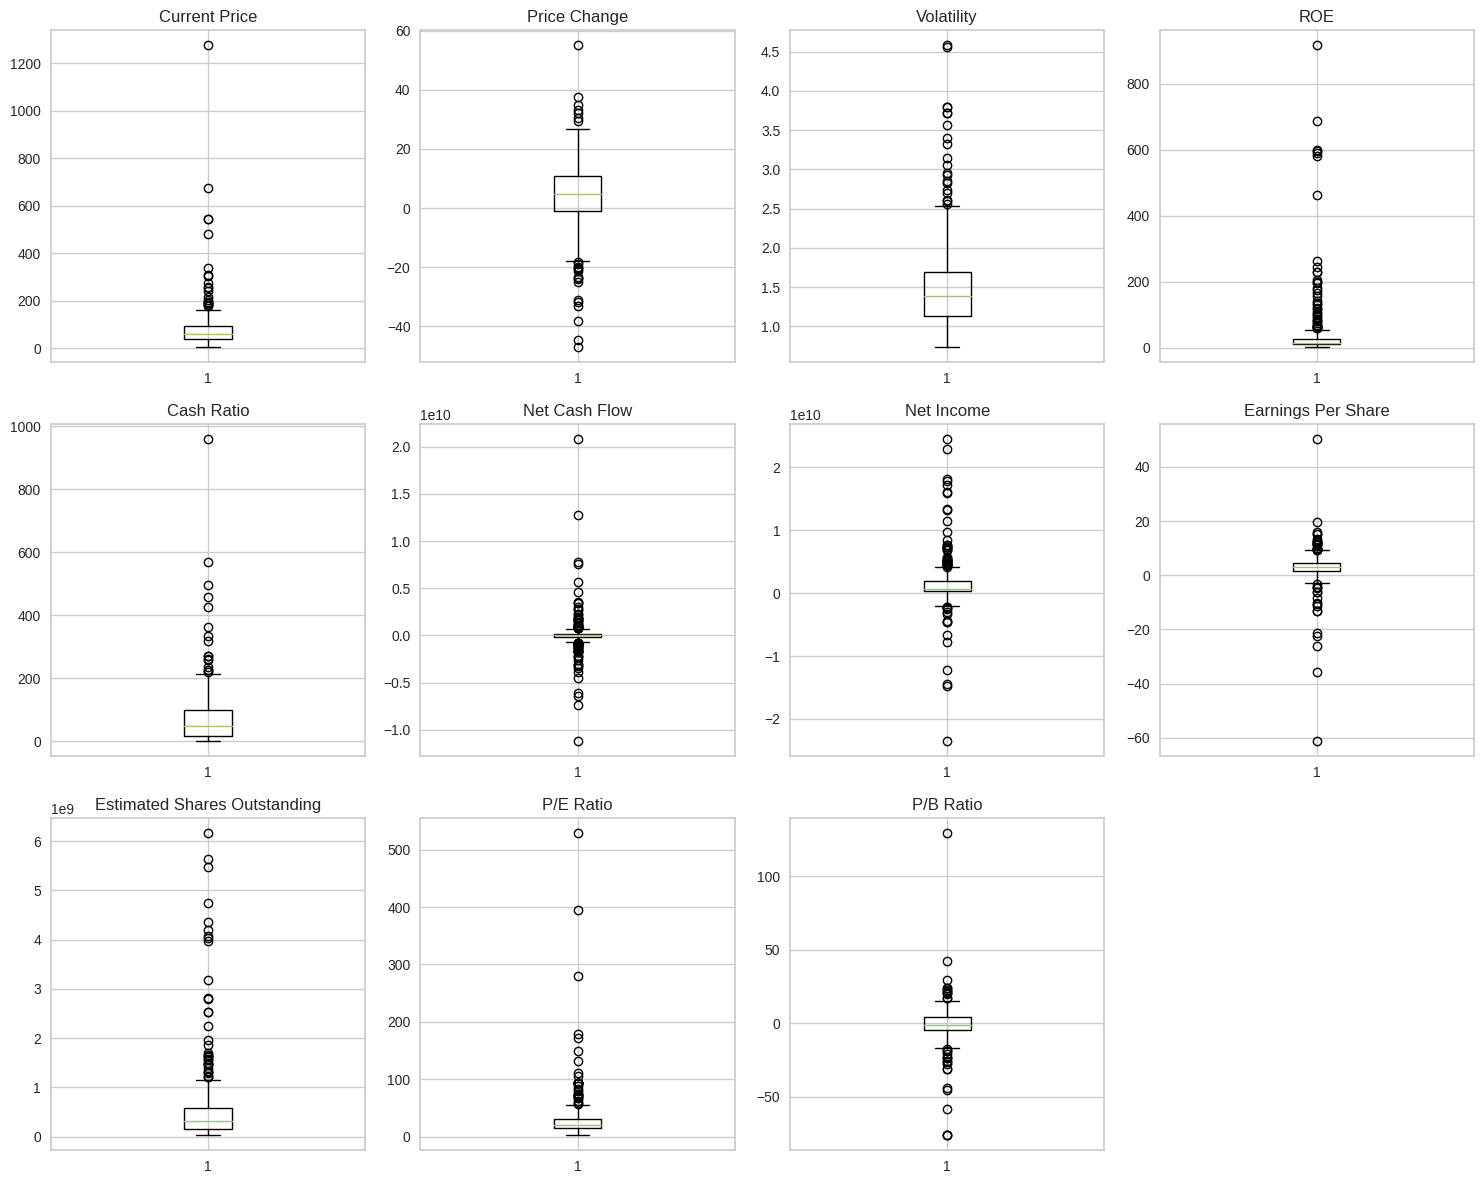

In [78]:
plt.figure(figsize=(15, 12))

numeric_columns = data.select_dtypes(include=np.number).columns.tolist()

for i, variable in enumerate(numeric_columns):
    plt.subplot(3, 4, i + 1)
    plt.boxplot(data[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

#### Observation: There are some outliers, but nothing out of the realm of possibility for actual stock prices, so no treatment is needed.



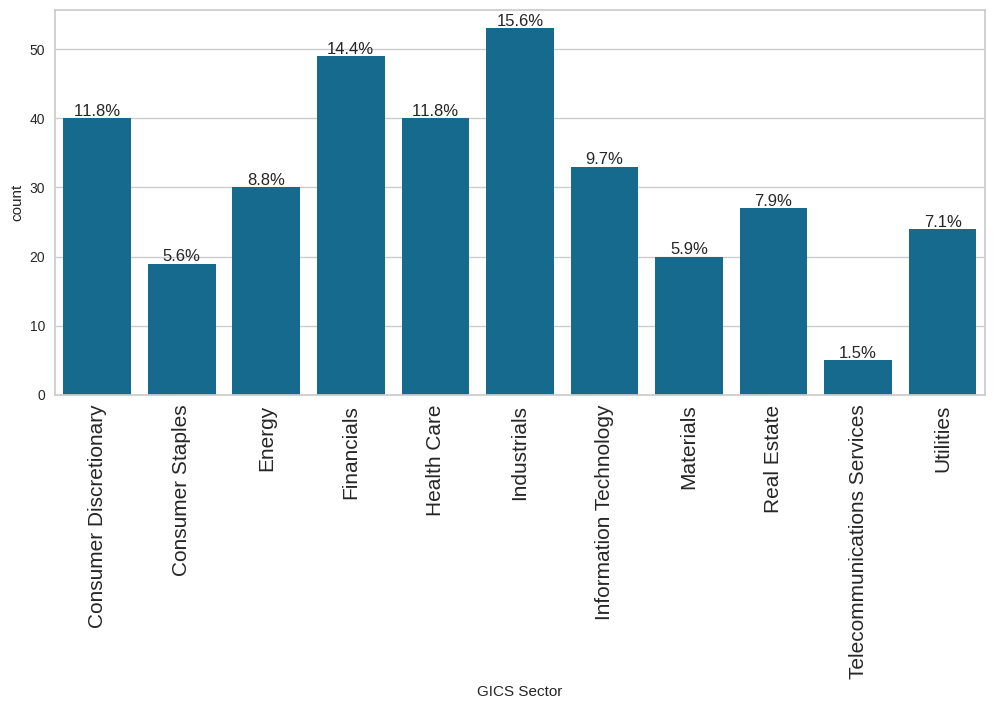

In [79]:
labeled_barplot(data, 'GICS Sector', perc=True)

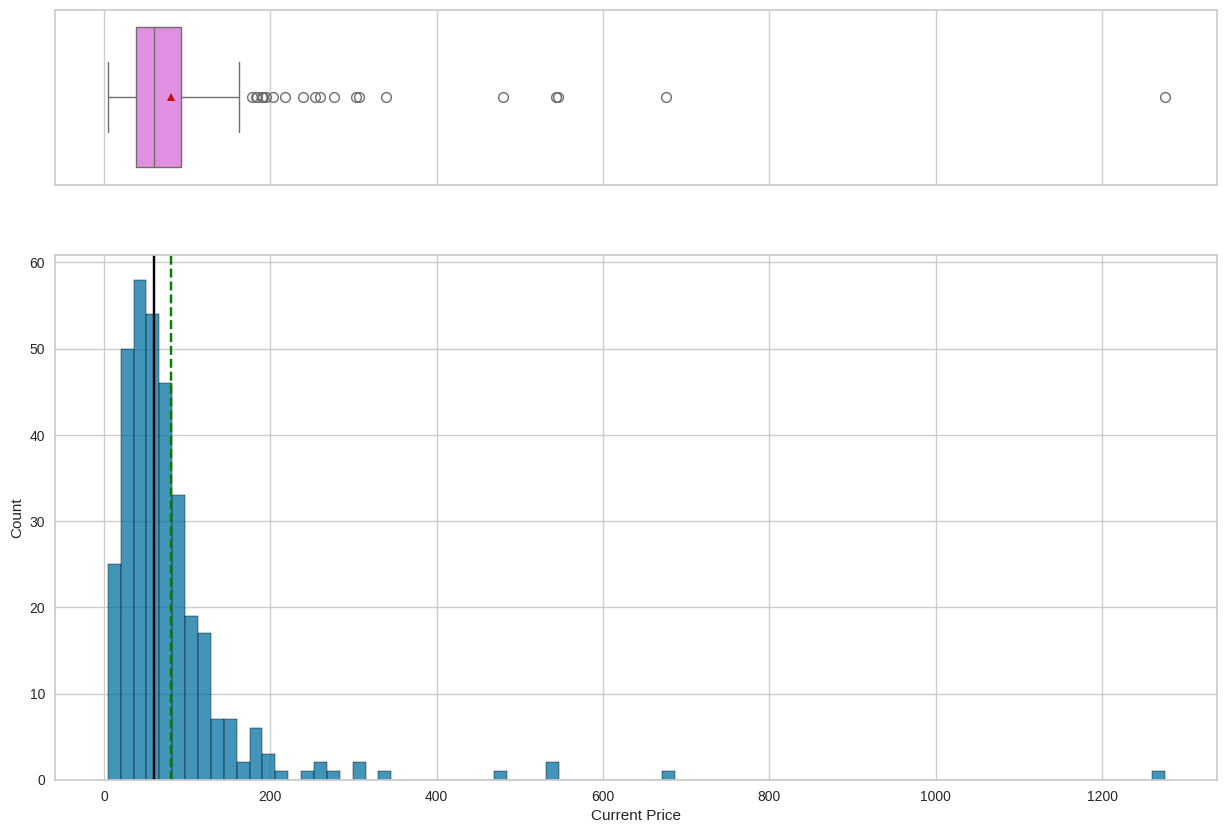

In [80]:
histogram_boxplot(data, "Current Price")

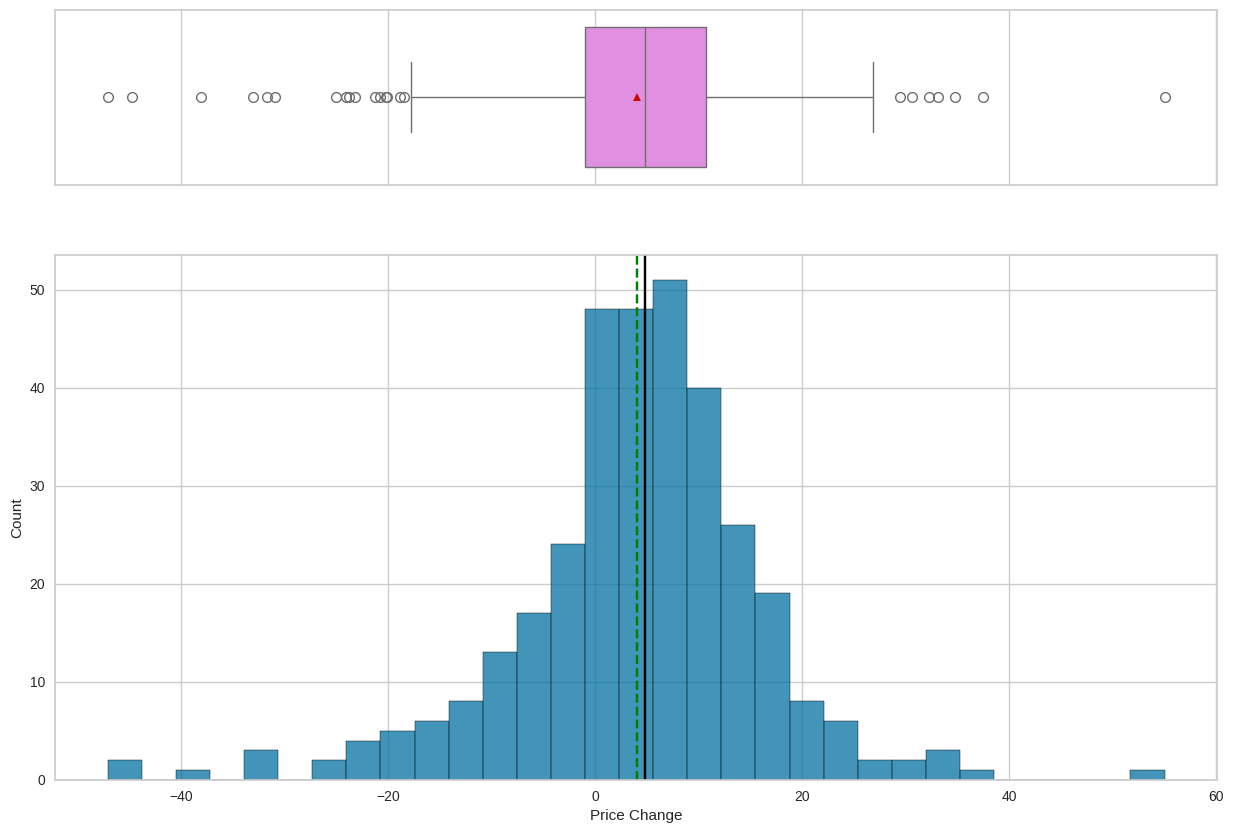

In [81]:
histogram_boxplot(data, "Price Change")

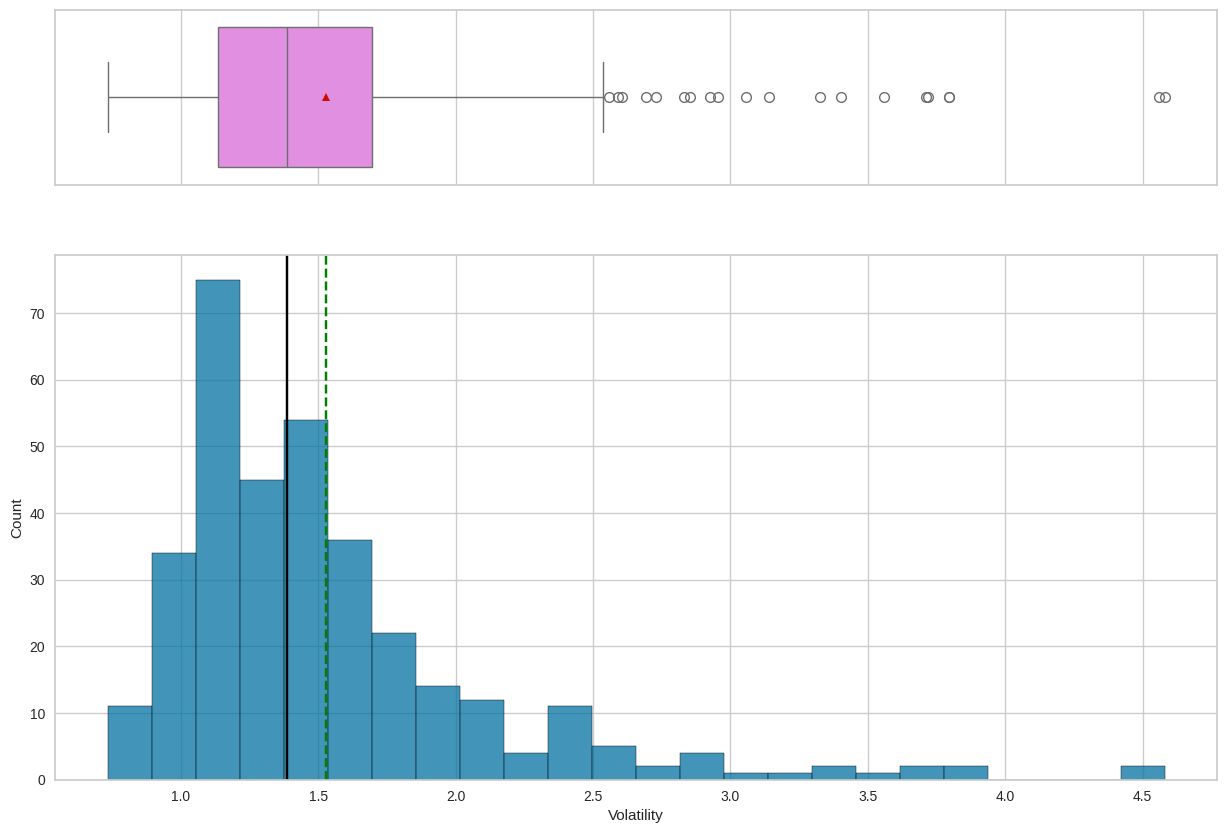

In [82]:
histogram_boxplot(data, "Volatility")

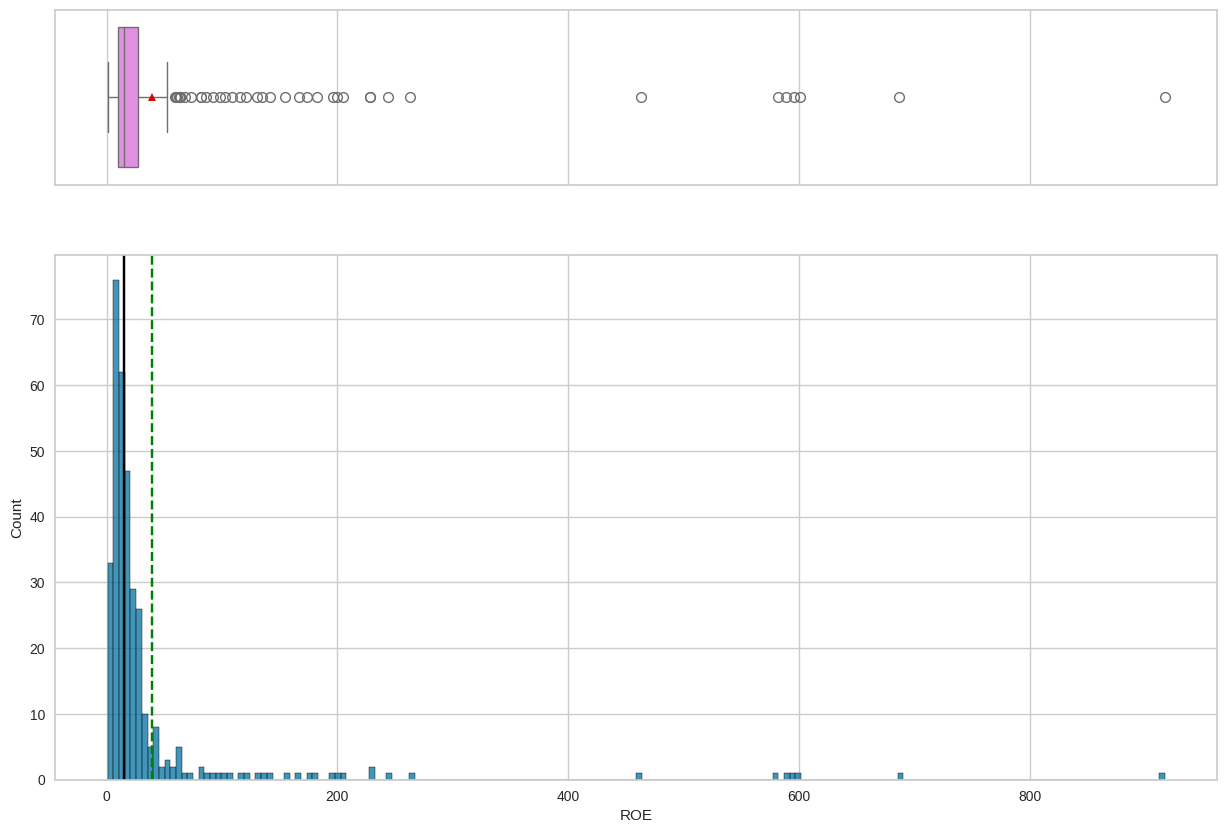

In [83]:
histogram_boxplot(data, "ROE")

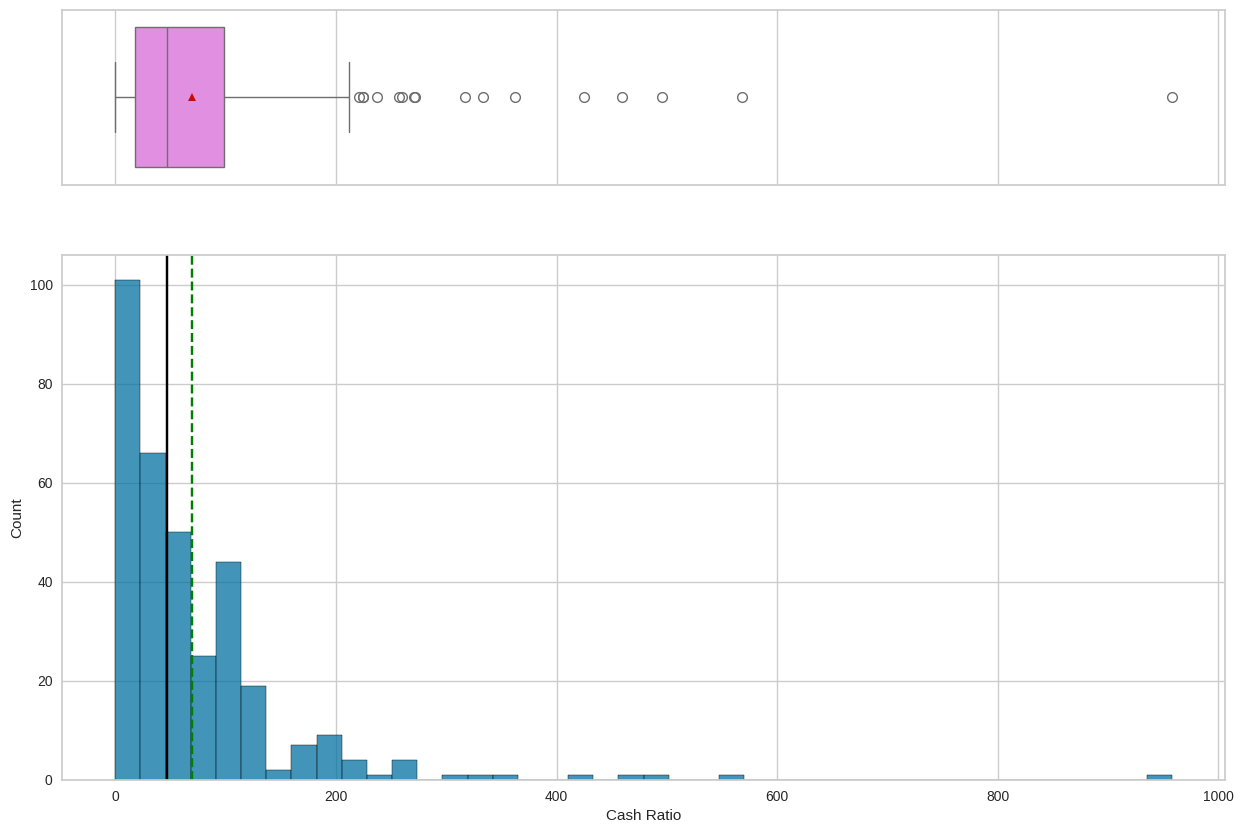

In [84]:
histogram_boxplot(data, "Cash Ratio")

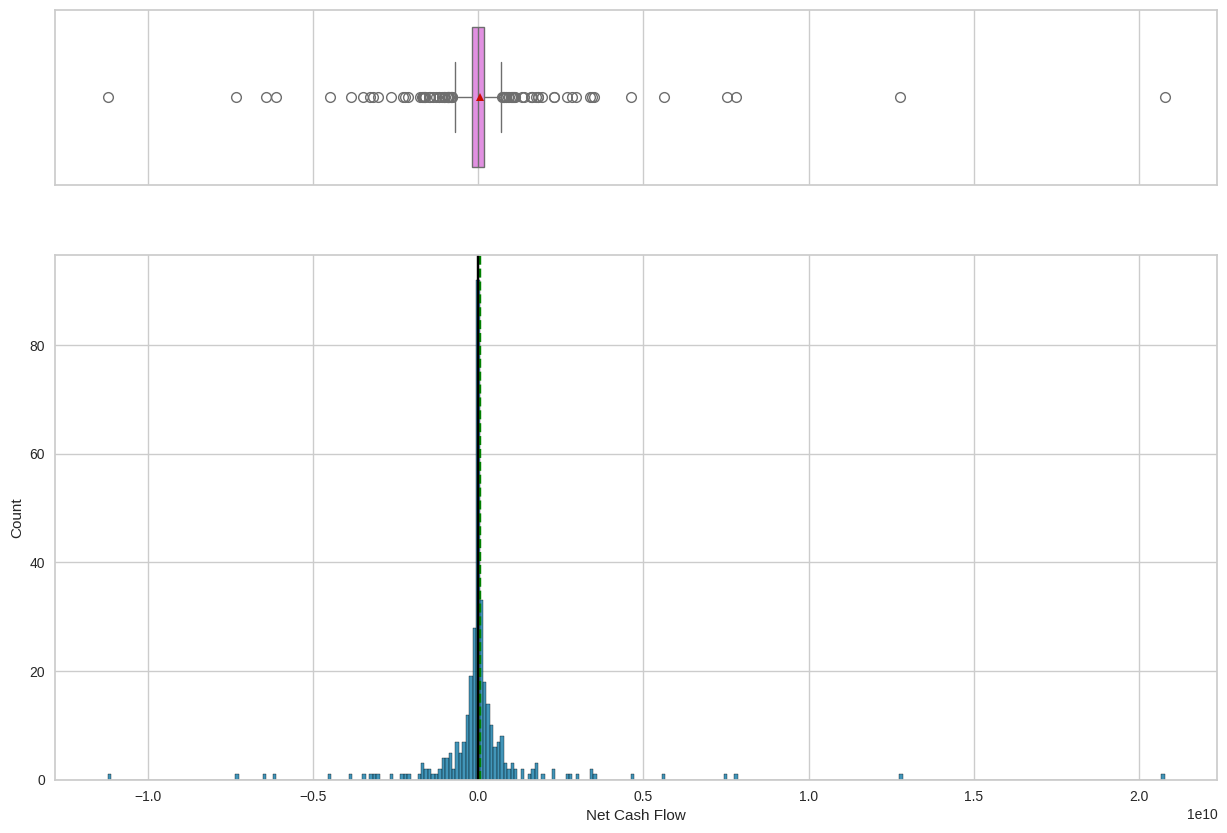

In [85]:
histogram_boxplot(data, "Net Cash Flow")

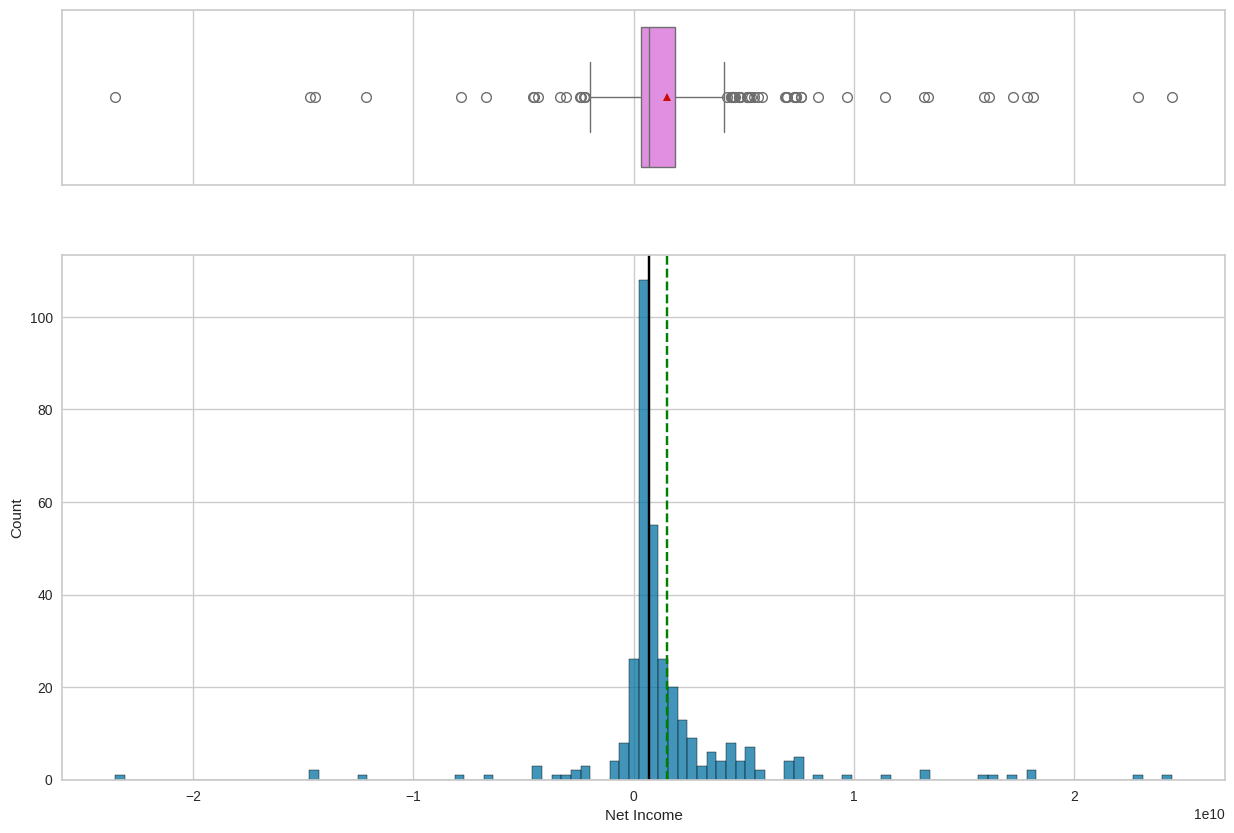

In [86]:
histogram_boxplot(data, "Net Income")

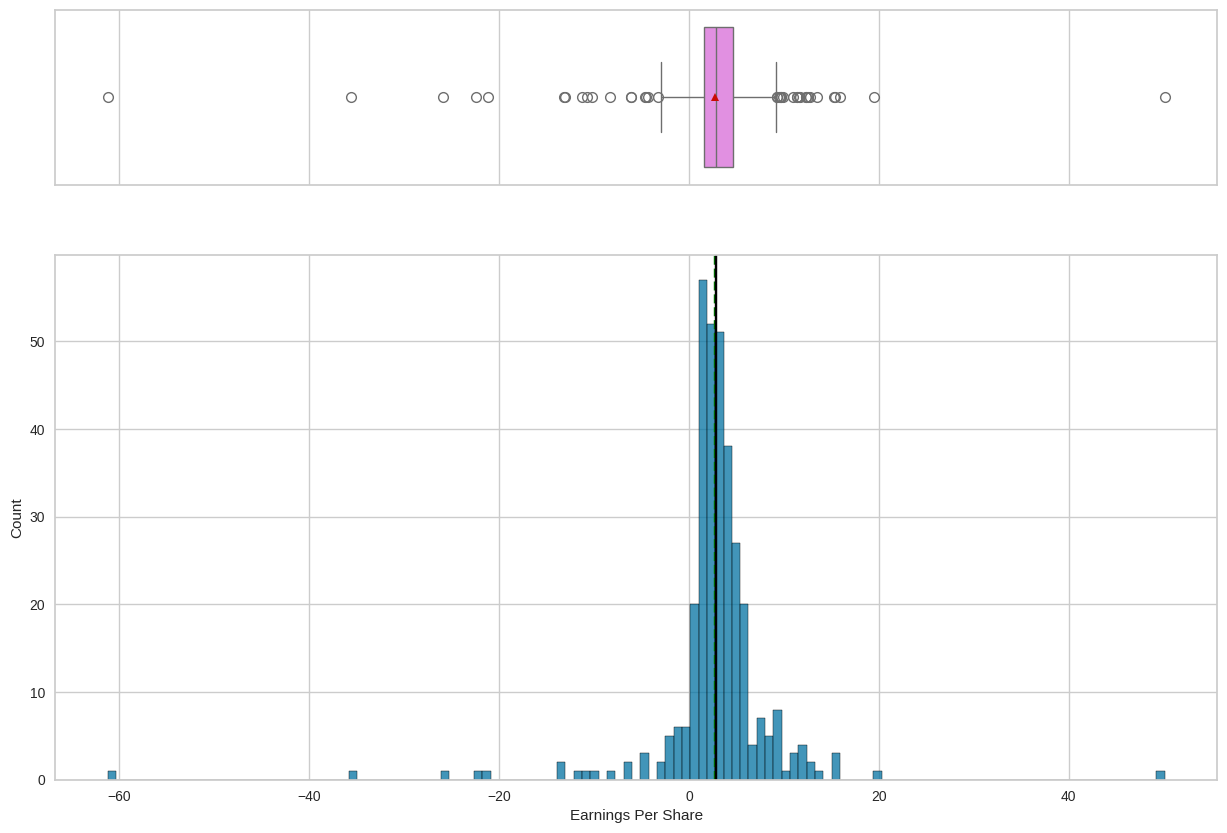

In [87]:
histogram_boxplot(data, "Earnings Per Share")

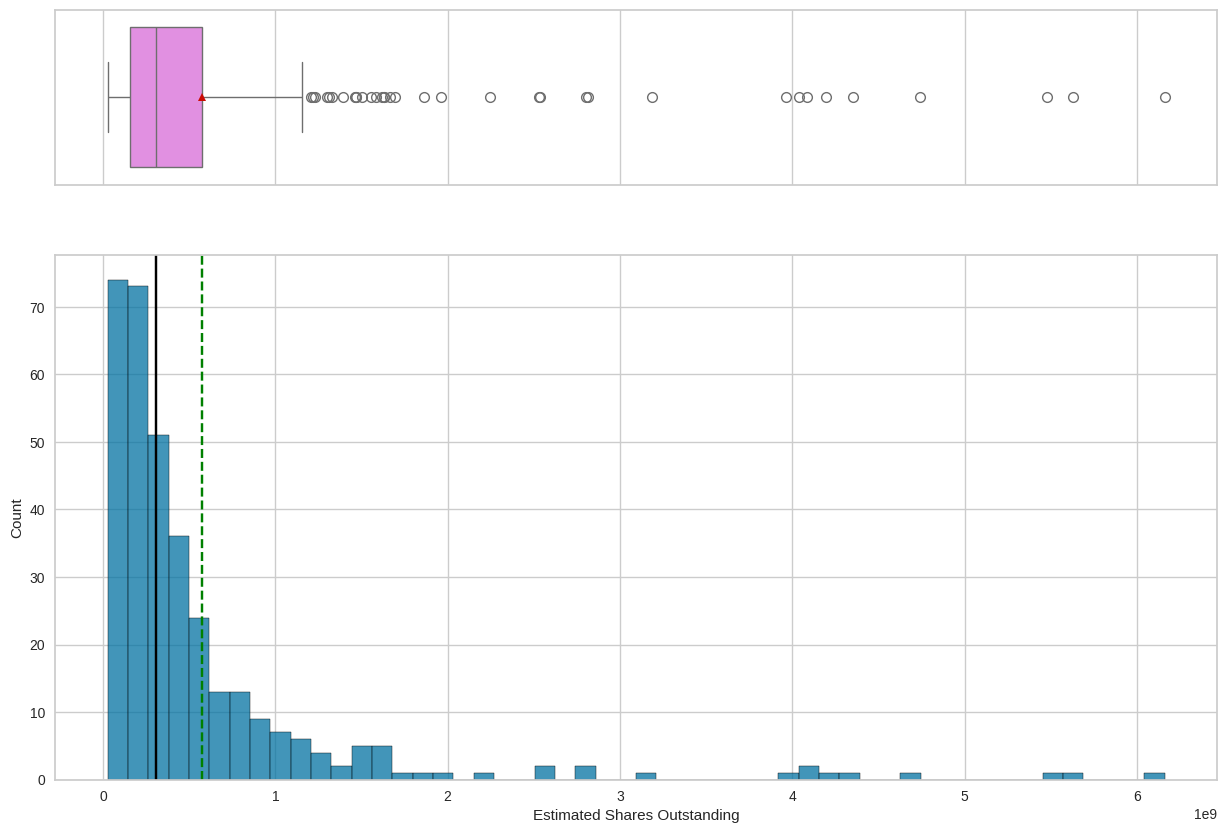

In [88]:
histogram_boxplot(data, "Estimated Shares Outstanding")

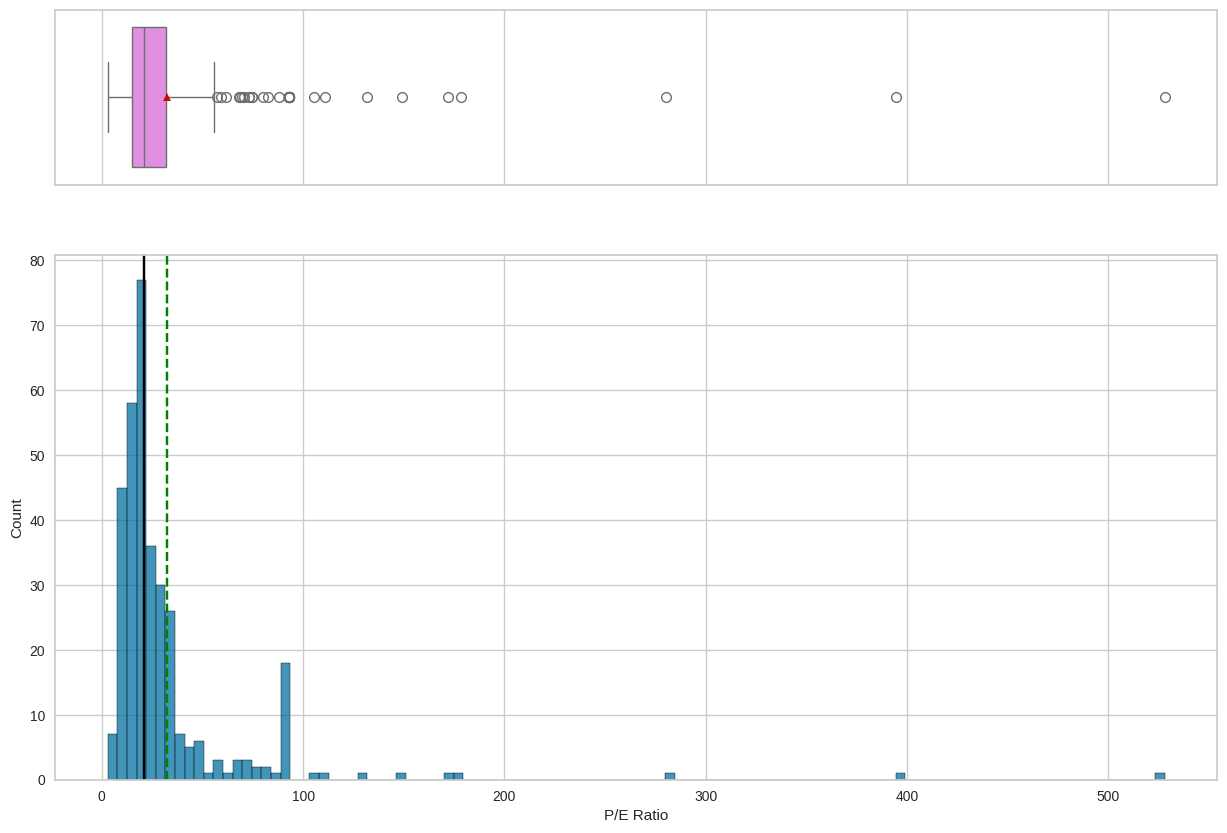

In [89]:
histogram_boxplot(data, "P/E Ratio")

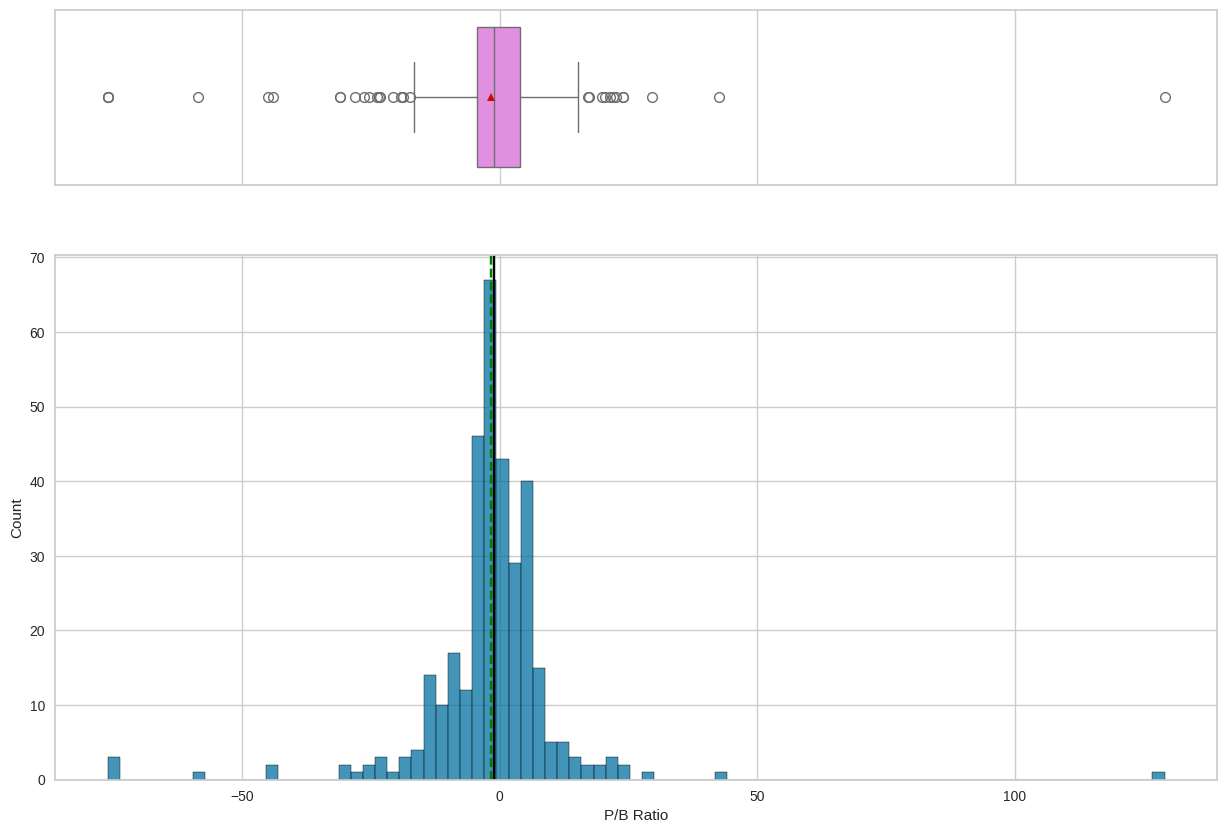

In [90]:
histogram_boxplot(data, "P/B Ratio")

#### Observation: Most of the data is normally distributed with some right skewing, but nothing too out of the ordinary, requiring feature engineering or outlier/missing data treatment. We can proceed with scaling the data.

### Scaling the data

In [91]:
#set up the scaler
scaler = StandardScaler()
subset = data.select_dtypes(include=np.number)
data_scaled = scaler.fit_transform(subset.select_dtypes(include=np.number))
#create a dataframe
scaled_df = pd.DataFrame(data_scaled, columns=subset.columns)

In [114]:
#view scaled data
scaled_df.head()

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,K_means_segments
0,-0.393341,0.493950,0.272749,0.989601,-0.210698,-0.339355,1.554415,1.309399,0.107863,-0.652487,-0.506653,0
1,-0.220837,0.355439,1.137045,0.937737,0.077269,-0.002335,0.927628,0.056755,1.250274,-0.311769,-0.504205,0
2,-0.367195,0.602479,-0.427007,-0.192905,-0.033488,0.454058,0.744371,0.024831,1.098021,-0.391502,0.094941,0
3,0.133567,0.825696,-0.284802,-0.317379,1.218059,-0.152497,-0.219816,-0.230563,-0.091622,0.947148,0.424333,0
4,-0.260874,-0.492636,0.296470,-0.265515,2.237018,0.133564,-0.202703,-0.374982,1.978399,3.293307,0.199196,1


## K-means Clustering

### Using Elbow Plot to find the Optimal Number of Clusters

Text(0.5, 1.0, 'Selecting k with the Elbow Method')

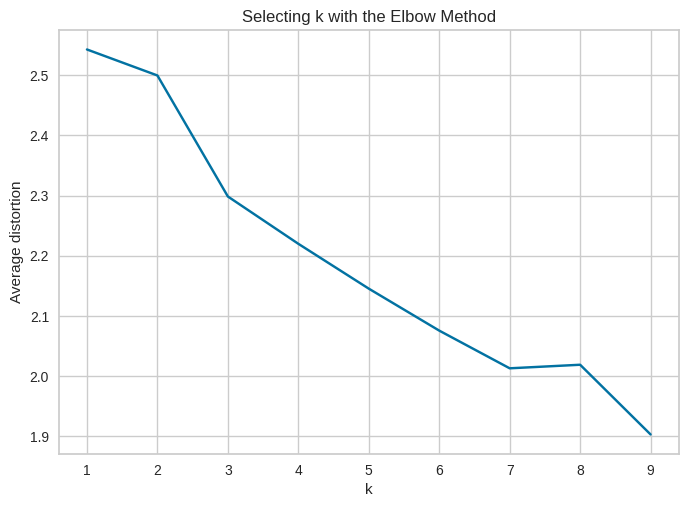

In [92]:
#Finding optimal no. of clusters
clusters=range(1,10)
meanDistortions=[]

for k in clusters:
    model=KMeans(n_clusters=k)
    model.fit(scaled_df)
    prediction=model.predict(scaled_df)
    meanDistortions.append(sum(np.min(cdist(scaled_df, model.cluster_centers_, 'euclidean'), axis=1)) / scaled_df.shape[0])


plt.plot(clusters, meanDistortions, 'bx-')
plt.xlabel('k')
plt.ylabel('Average distortion')
plt.title('Selecting k with the Elbow Method')


#### Observation: there are bends at 2, 3 and 6.

### Check the silhouette score

For n_clusters = 2, silhouette score is 0.43969639509980457
For n_clusters = 3, silhouette score is 0.5407377502585806
For n_clusters = 4, silhouette score is 0.4527048727189205
For n_clusters = 5, silhouette score is 0.3770625918623543
For n_clusters = 6, silhouette score is 0.3863465606304045
For n_clusters = 7, silhouette score is 0.3929887629804409
For n_clusters = 8, silhouette score is 0.35927058729308975
For n_clusters = 9, silhouette score is 0.3409307221266928


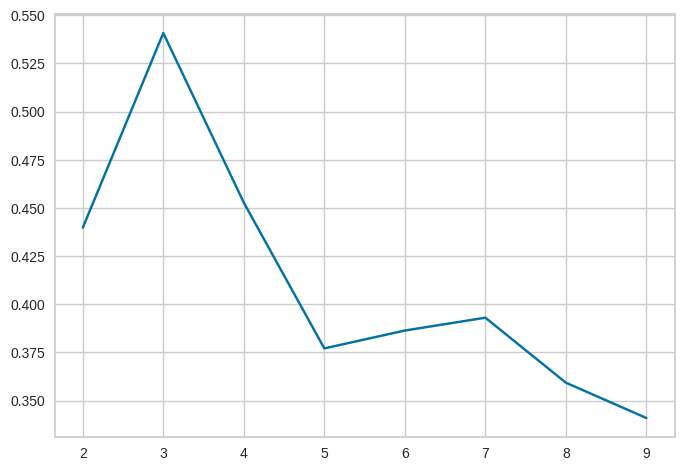

In [93]:
sil_score = []
cluster_list = list(range(2, 10))
for n_clusters in cluster_list:
    clusterer = KMeans(n_clusters=n_clusters)
    preds = clusterer.fit_predict((scaled_df))
    # centers = clusterer.cluster_centers_
    score = silhouette_score(scaled_df, preds)
    sil_score.append(score)
    print("For n_clusters = {}, silhouette score is {}".format(n_clusters, score))

plt.plot(cluster_list, sil_score)

#### Observation: Silhouette score is best for 2 clusters.

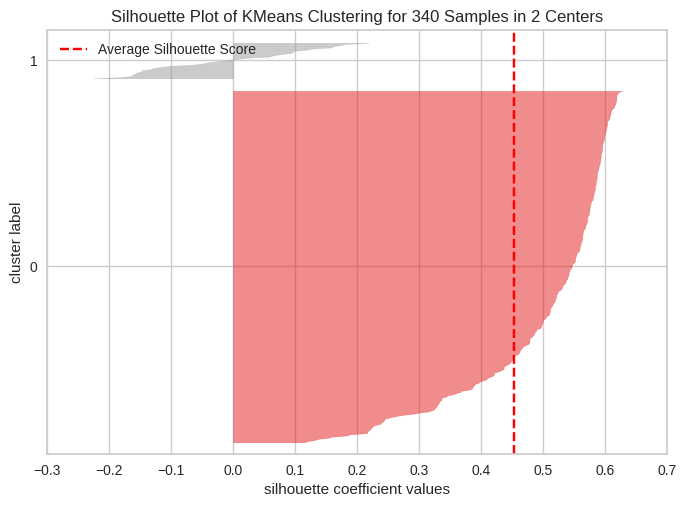

<Axes: title={'center': 'Silhouette Plot of KMeans Clustering for 340 Samples in 2 Centers'}, xlabel='silhouette coefficient values', ylabel='cluster label'>

In [94]:
# finding optimal no. of clusters with silhouette coefficients
visualizer = SilhouetteVisualizer(KMeans(2, random_state=1))
visualizer.fit(scaled_df)
visualizer.show()

### K-means: creating the final model

#### Two clusters performed best, so we will proceed with that choice as our model.

In [95]:
#create and fit the final kmeans model
kmeans = KMeans(n_clusters=2, random_state=1)
kmeans.fit(scaled_df)

KMeans(n_clusters=2, random_state=1)

In [96]:
#add kmeans cluster labels to original dataframes

# Add labels to the original dataframe
scaled_df["K_means_segments"] = kmeans.labels_
data["K_means_segments"] = kmeans.labels_



In [97]:
km_cluster_profile = data.groupby("K_means_segments").apply(lambda x: x.select_dtypes(include=['float64', 'int64']).mean())
km_cluster_profile

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio
K_means_segments,,,,,,,,,,,
0,82.111257,5.570491,1.394712,31.782468,70.564935,7.004323e+07,1.986010e+09,3.889886,5.846779e+08,24.668434,-1.778604
1,68.841564,-10.285163,2.789397,114.812500,64.812500,-8.407888e+07,-3.237506e+09,-7.938125,5.034017e+08,109.074811,-1.137335


### Kmeans Cluster Profiling

In [98]:

km_cluster_profile["count_in_each_segment"] = (
    data.groupby("K_means_segments")["Security"].count().values
)

In [99]:
km_cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,count_in_each_segment
K_means_segments,,,,,,,,,,,,
0,82.111257,5.570491,1.394712,31.782468,70.564935,70043230.519481,1986009597.402597,3.889886,584677860.238409,24.668434,-1.778604,308
1,68.841564,-10.285163,2.789397,114.812500,64.812500,-84078875.000000,-3237505968.750000,-7.938125,503401683.841875,109.074811,-1.137335,32


#### There are 320 observations in group 0 and 32 in group 1.

In [100]:
#Look at companies in each cluster
for cluster_num, group in data.groupby('K_means_segments'):
    print(f"Companies in Cluster {cluster_num}:")
    print(group["Security"].values)
    print("\n")  # add space between clusters

Companies in Cluster 0:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Adobe Systems Inc' 'Archer-Daniels-Midland Co' 'Alliance Data Systems'
 'Ameren Corp' 'American Electric Power' 'AFLAC Inc'
 'American International Group, Inc.' 'Apartment Investment & Mgmt'
 'Assurant Inc' 'Arthur J. Gallagher & Co.' 'Akamai Technologies Inc'
 'Albemarle Corp' 'Alaska Air Group Inc' 'Allstate Corp' 'Allegion'
 'Applied Materials Inc' 'AMETEK Inc' 'Affiliated Managers Group Inc'
 'Amgen Inc' 'Ameriprise Financial' 'American Tower Corp A'
 'AutoNation Inc' 'Anthem Inc.' 'Aon plc' 'Amphenol Corp' 'Arconic Inc'
 'Activision Blizzard' 'AvalonBay Communities, Inc.' 'Broadcom'
 'American Water Works Company Inc' 'American Express Co' 'Boeing Company'
 'Bank of America Corp' 'Baxter International Inc.' 'BB&T Corporation'
 'Bard (C.R.) Inc.' 'BIOGEN IDEC Inc.' 'The Bank of New York Mellon Corp.'
 'Ball Corp' 'Bristol-Myers Squibb' 'Boston Scientific' 'BorgWarner'
 'Boston Properties' 'Citigrou

## Hierarchical Clustering

### Cophenetic Correlation

In [101]:
# list of distance metrics
distance_metrics = ["euclidean", "chebyshev", "mahalanobis", "cityblock"]

# list of linkage methods
linkage_methods = ["single", "complete", "average", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for dm in distance_metrics:
    for lm in linkage_methods:
        Z = linkage(scaled_df, metric=dm, method=lm)
        c, coph_dists = cophenet(Z, pdist(data_scaled))
        print(
            "Cophenetic correlation for {} distance and {} linkage is {}.".format(
                dm.capitalize(), lm, c
            )
        )
        if high_cophenet_corr < c:
            high_cophenet_corr = c
            high_dm_lm[0] = dm
            high_dm_lm[1] = lm

Cophenetic correlation for Euclidean distance and single linkage is 0.923501736848571.
Cophenetic correlation for Euclidean distance and complete linkage is 0.8040513008854757.
Cophenetic correlation for Euclidean distance and average linkage is 0.9421419296295791.
Cophenetic correlation for Euclidean distance and weighted linkage is 0.9103840483596123.
Cophenetic correlation for Chebyshev distance and single linkage is 0.9064347800092791.
Cophenetic correlation for Chebyshev distance and complete linkage is 0.8035944914642504.
Cophenetic correlation for Chebyshev distance and average linkage is 0.9338260206954379.
Cophenetic correlation for Chebyshev distance and weighted linkage is 0.893574599451016.
Cophenetic correlation for Mahalanobis distance and single linkage is 0.90919631914706.
Cophenetic correlation for Mahalanobis distance and complete linkage is 0.6760213733638829.
Cophenetic correlation for Mahalanobis distance and average linkage is 0.9309410053637275.
Cophenetic correl

In [102]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} distance and {} linkage.".format(
        high_cophenet_corr, high_dm_lm[0].capitalize(), high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.9421419296295791, which is obtained with Euclidean distance and average linkage.


In [103]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

high_cophenet_corr = 0
high_dm_lm = [0, 0]

for lm in linkage_methods:
    Z = linkage(scaled_df, metric="euclidean", method=lm)
    c, coph_dists = cophenet(Z, pdist(scaled_df))
    print("Cophenetic correlation for {} linkage is {}.".format(lm, c))
    if high_cophenet_corr < c:
        high_cophenet_corr = c
        high_dm_lm[0] = "euclidean"
        high_dm_lm[1] = lm

Cophenetic correlation for single linkage is 0.9232707363974292.
Cophenetic correlation for complete linkage is 0.8090526321713777.
Cophenetic correlation for average linkage is 0.9425701364620629.
Cophenetic correlation for centroid linkage is 0.9409335762134008.
Cophenetic correlation for ward linkage is 0.7181446537248168.
Cophenetic correlation for weighted linkage is 0.9105502644066915.


#### Observation: Average linkage performed the best with .942

In [104]:
# printing the combination of distance metric and linkage method with the highest cophenetic correlation
print(
    "Highest cophenetic correlation is {}, which is obtained with {} linkage.".format(
        high_cophenet_corr, high_dm_lm[1]
    )
)

Highest cophenetic correlation is 0.9425701364620629, which is obtained with average linkage.


### Checking Dendrograms

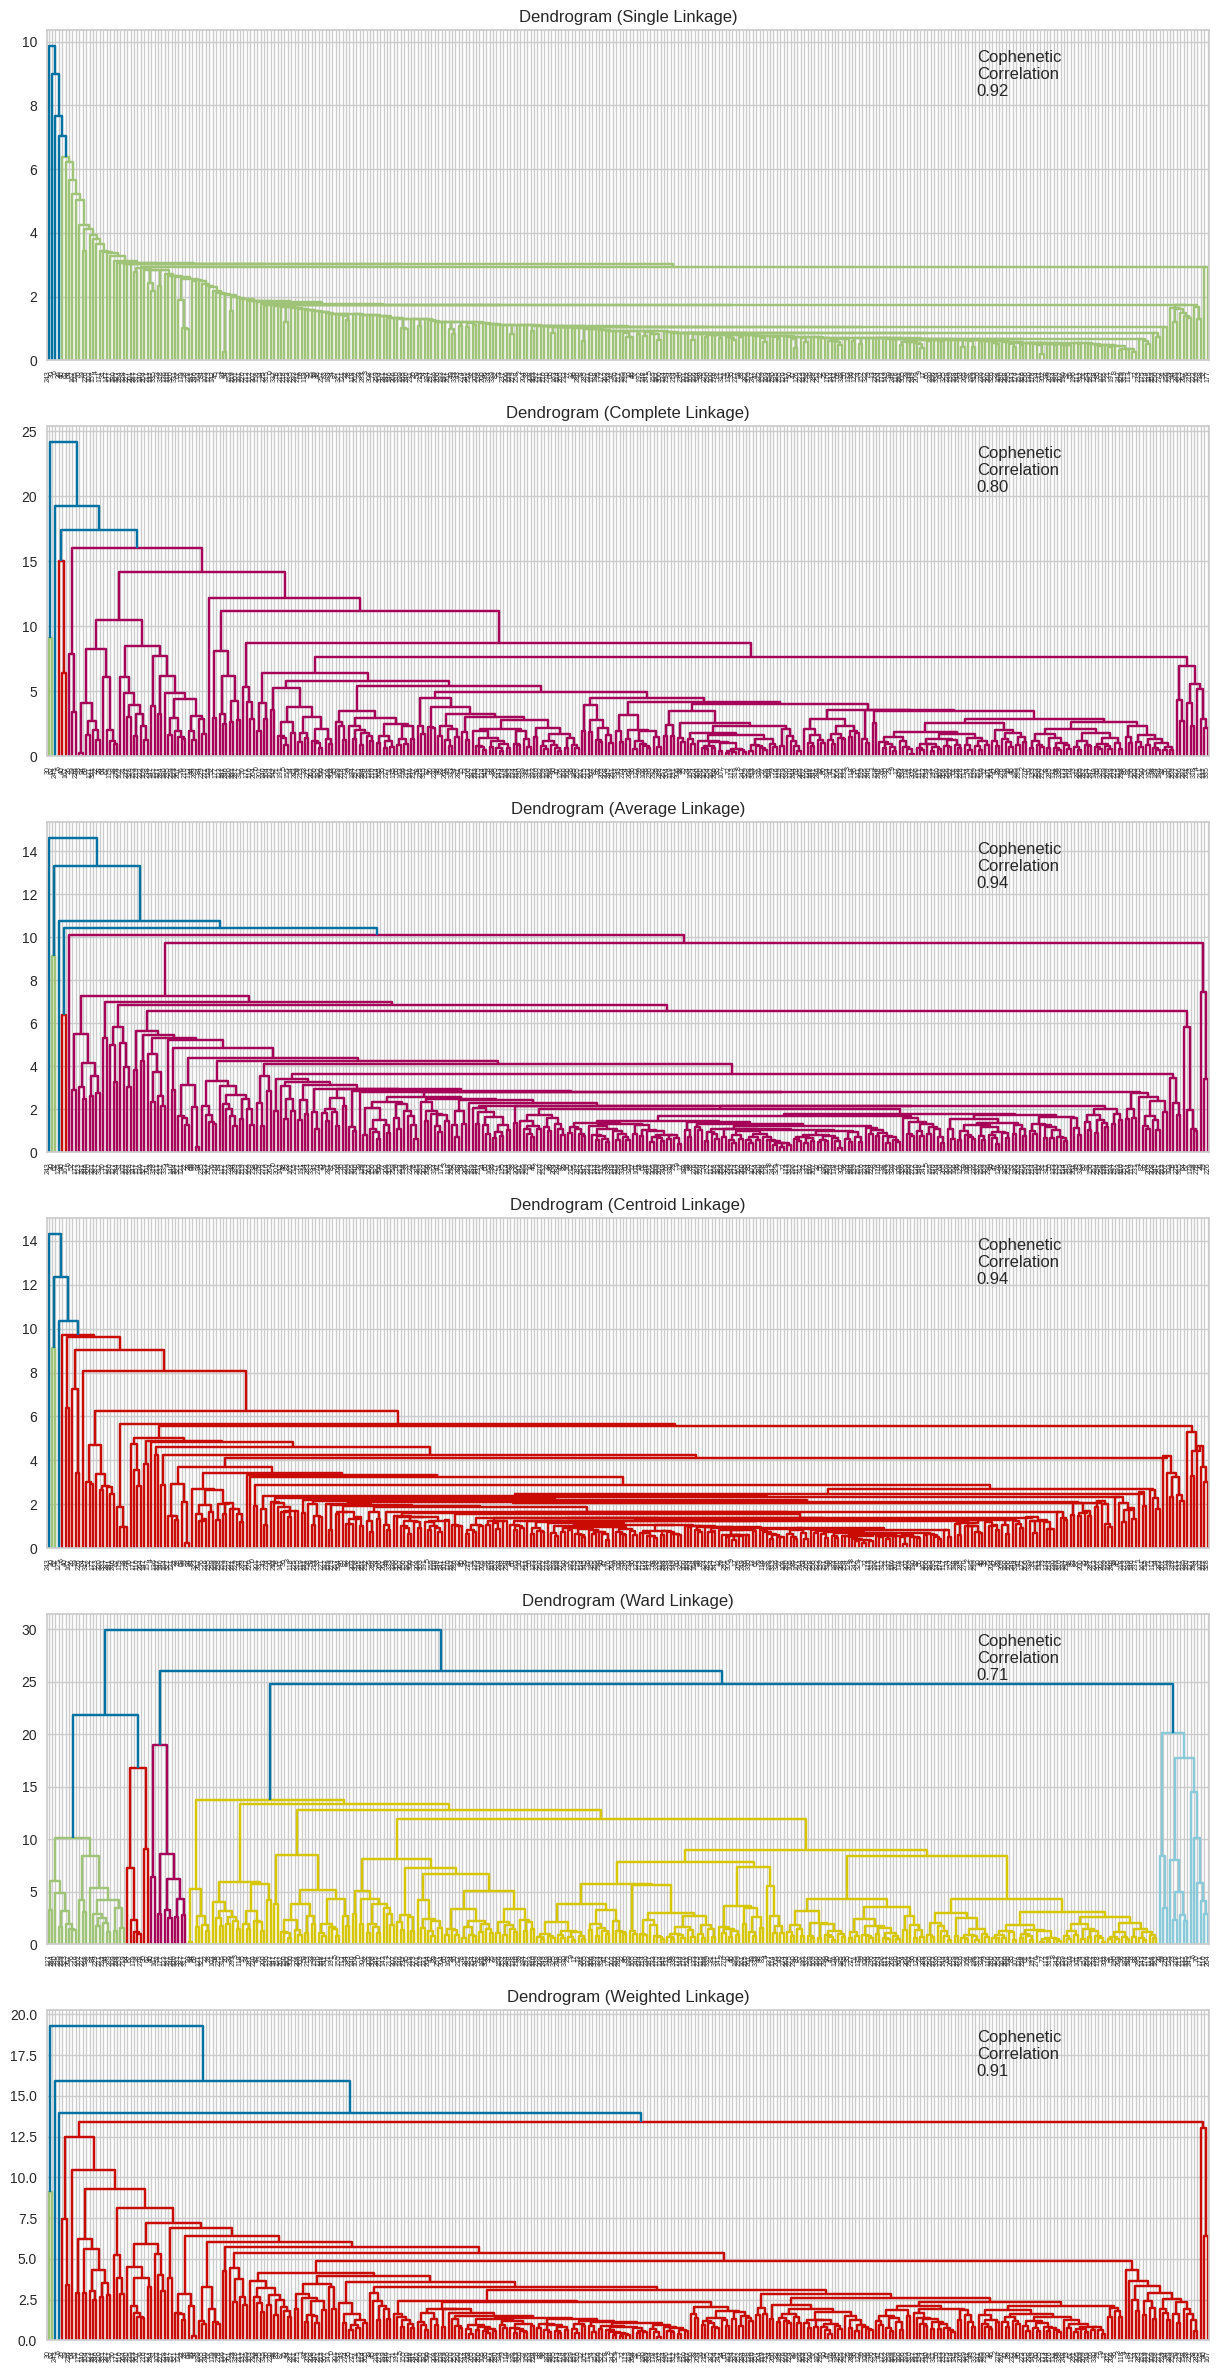

In [105]:
# list of linkage methods
linkage_methods = ["single", "complete", "average", "centroid", "ward", "weighted"]

# lists to save results of cophenetic correlation calculation
compare_cols = ["Linkage", "Cophenetic Coefficient"]

# to create a subplot image
fig, axs = plt.subplots(len(linkage_methods), 1, figsize=(15, 30))

# We will enumerate through the list of linkage methods above
# For each linkage method, we will plot the dendrogram and calculate the cophenetic correlation
for i, method in enumerate(linkage_methods):
    Z = linkage(scaled_df, metric="euclidean", method=method)

    dendrogram(Z, ax=axs[i])
    axs[i].set_title(f"Dendrogram ({method.capitalize()} Linkage)")

    coph_corr, coph_dist = cophenet(Z, pdist(data_scaled))
    axs[i].annotate(
        f"Cophenetic\nCorrelation\n{coph_corr:0.2f}",
        (0.80, 0.80),
        xycoords="axes fraction",
    )

#### It looks like average linkage with 3 or 4 clusters will work. Let's try both.

### HC Checking the Silhouette Score

In [106]:

# Fit the model with 3 clusters
HCmodel_3 = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="average")
labels_3 = HCmodel_3.fit_predict(scaled_df)

# Calculate the silhouette score for 3 clusters
silhouette_3 = silhouette_score(scaled_df, labels_3)
print(f"Silhouette Score for 3 clusters: {silhouette_3}")

# Fit the model with 4 clusters
HCmodel_4 = AgglomerativeClustering(n_clusters=4, metric="euclidean", linkage="average")
labels_4 = HCmodel_4.fit_predict(scaled_df)

# Calculate the silhouette score for 4 clusters
silhouette_4 = silhouette_score(scaled_df, labels_4)
print(f"Silhouette Score for 4 clusters: {silhouette_4}")

# Compare the results
if silhouette_3 > silhouette_4:
    print("The 3-cluster model performs better.")
else:
    print("The 4-cluster model performs better.")



Silhouette Score for 3 clusters: 0.7137934704555429
Silhouette Score for 4 clusters: 0.6500530357567537
The 3-cluster model performs better.


#### Observation:
Silhouette Score for 3 clusters: 0.7137934704555429
Silhouette Score for 4 clusters: 0.6500530357567537
The 3-cluster model performs better so we will proceed with that for our final model.

In [107]:
#Final Model

HCmodel_3 = AgglomerativeClustering(n_clusters=3, metric="euclidean", linkage="average")
labels_3 = HCmodel_3.fit_predict(scaled_df)
data["HC_Clusters"] = labels_3

### HC Cluster Profiling

In [108]:
cluster_profile = data.groupby("HC_Clusters").apply(lambda x: x.select_dtypes(include=['float64', 'int64']).mean())

In [109]:
cluster_profile["count_in_each_segment"] = (
    data.groupby("HC_Clusters")["Security"].count().values
)

In [110]:
cluster_profile.style.highlight_max(color="lightgreen", axis=0)

,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,HC_Clusters,count_in_each_segment
HC_Clusters,,,,,,,,,,,,,
0,77.653642,4.184271,1.515129,35.103858,69.798220,68662246.290801,1613508620.178041,2.900905,578930419.447478,32.466828,-1.739711,0.000000,337
1,1274.949951,3.190527,1.268340,29.000000,184.000000,-1671386000.000000,2551360000.000000,50.090000,50935516.070000,25.453183,-1.052429,1.000000,1
2,24.485001,-13.351992,3.482611,802.000000,51.000000,-1292500000.000000,-19106500000.000000,-41.815000,519573983.250000,60.748608,1.565141,2.000000,2


In [111]:
for cl in data["HC_Clusters"].unique():
    print("In cluster {}, the following companies are present:".format(cl))
    print(data[data["HC_Clusters"] == cl]["Security"].unique())
    print()

In cluster 0, the following companies are present:
['American Airlines Group' 'AbbVie' 'Abbott Laboratories'
 'Adobe Systems Inc' 'Analog Devices, Inc.' 'Archer-Daniels-Midland Co'
 'Alliance Data Systems' 'Ameren Corp' 'American Electric Power'
 'AFLAC Inc' 'American International Group, Inc.'
 'Apartment Investment & Mgmt' 'Assurant Inc' 'Arthur J. Gallagher & Co.'
 'Akamai Technologies Inc' 'Albemarle Corp' 'Alaska Air Group Inc'
 'Allstate Corp' 'Allegion' 'Alexion Pharmaceuticals'
 'Applied Materials Inc' 'AMETEK Inc' 'Affiliated Managers Group Inc'
 'Amgen Inc' 'Ameriprise Financial' 'American Tower Corp A'
 'Amazon.com Inc' 'AutoNation Inc' 'Anthem Inc.' 'Aon plc'
 'Anadarko Petroleum Corp' 'Amphenol Corp' 'Arconic Inc'
 'Activision Blizzard' 'AvalonBay Communities, Inc.' 'Broadcom'
 'American Water Works Company Inc' 'American Express Co' 'Boeing Company'
 'Bank of America Corp' 'Baxter International Inc.' 'BB&T Corporation'
 'Bard (C.R.) Inc.' 'Baker Hughes Inc' 'BIOGEN IDEC I

## K-means vs Hierarchical Clustering

You compare several things, like:
- Which clustering technique took less time for execution?
- Which clustering technique gave you more distinct clusters, or are they the same?
- How many observations are there in the similar clusters of both algorithms?
- How many clusters are obtained as the appropriate number of clusters from both algorithms?

You can also mention any differences or similarities you obtained in the cluster profiles from both the clustering techniques.

## Actionable Insights and Recommendations
Most recent run times while in development are as follows (but these tended to vary depending on the time of day that I was working). KMeans was slightly faster than Hierarchical clustering.

**Kmeans:**
CPU times: user 10.8 ms, sys: 7.43 ms, total: 18.2 ms
Wall time: 6.45 ms

Silhouette score was best for 2 clusters at 0.5764.

**Hierarchical Clustering:**
CPU times: user 12.9 ms, sys: 29.7 ms, total: 42.6 ms
Wall time: 6.52 ms

Silhouette score of  0.714 was best for 3 clusters.

Highest cophenetic correlation is 0.9425701364620629, which was obtained with average linkage.

K-means had a little faster run time, but overall, Hierarchical Clustering did a little better job of sorting the securities into clusters that made sense. The companies that HC put into other groups like Chesapeake Energy and Apache Corp in group 1 were underperforming compared to other stocks. Priceline in group 2 had a much higher stock price than any other stock and seemed to be outperforming other stocks (see data below). This distinction was not as obvious with the K-means method, where these companies got grouped in with others that were less similar.

Overall, I would recommend the use of Hierarchical Clustering for this use case.

In [112]:
data[data['Security'].isin(['Apache Corporation', 'Chesapeake Energy', 'Priceline.com Inc'])]

,Ticker Symbol,Security,GICS Sector,GICS Sub Industry,Current Price,Price Change,Volatility,ROE,Cash Ratio,Net Cash Flow,Net Income,Earnings Per Share,Estimated Shares Outstanding,P/E Ratio,P/B Ratio,K_means_segments,HC_Clusters
30,APA,Apache Corporation,Energy,Oil & Gas Exploration & Production,44.470001,11.397804,2.405408,917,80,698000000,-23528000000,-61.20,3.844444e+08,93.089287,4.970809,1,2
62,CHK,Chesapeake Energy,Energy,Integrated Oil & Gas,4.500000,-38.101788,4.559815,687,22,-3283000000,-14685000000,-22.43,6.547035e+08,28.407929,-1.840528,1,2
243,PCLN,Priceline.com Inc,Consumer Discretionary,Internet & Direct Marketing Retail,1274.949951,3.190527,1.268340,29,184,-1671386000,2551360000,50.09,5.093552e+07,25.453183,-1.052429,0,1
